In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Add src to path
sys.path.append('../src')

from data_collection import DataCollector
from preprocessing import DataPreprocessor

# Set up plotting
# plt.style.use('seaborn')
sns.set_palette("husl")


In [3]:
# Initialize components
collector = DataCollector()
preprocessor = DataPreprocessor()

# Configuration
ticker = 'AAPL'
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

print(f"Collecting data for {ticker} from {start_date.date()} to {end_date.date()}")


In [4]:
# Collect stock data
stock_data = collector.get_stock_data_yahoo(ticker, start_date, end_date)
print(f"Collected {len(stock_data)} days of data")
stock_data.head()


[*********************100%***********************]  1 of 1 completed

Collected 251 days of data


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-02-24,246.027710,247.780067,243.359332,243.867113,51326400
2025-02-25,245.967957,248.915118,243.847210,246.923797,48013300
2025-02-26,239.316956,243.916902,238.092297,243.269729,44433600
2025-02-27,236.270248,241.407860,236.031284,238.371093,41153600
2025-02-28,240.790527,241.039442,229.201040,235.921748,56833400


In [5]:
# Basic statistics
stock_data.describe()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,235.457503,238.044984,232.862446,235.345922,5.405064e+07
std,28.682901,28.550385,28.854141,28.787727,2.311303e+07
min,171.671783,189.514018,168.475722,171.203815,1.791060e+07
25%,209.377846,211.402696,207.277780,209.377843,4.130020e+07
50%,233.904175,235.523478,230.410852,234.089740,4.801330e+07
75%,261.927917,264.615005,258.827297,261.695915,5.656205e+07
max,285.922455,288.350192,283.035157,285.932471,1.843959e+08


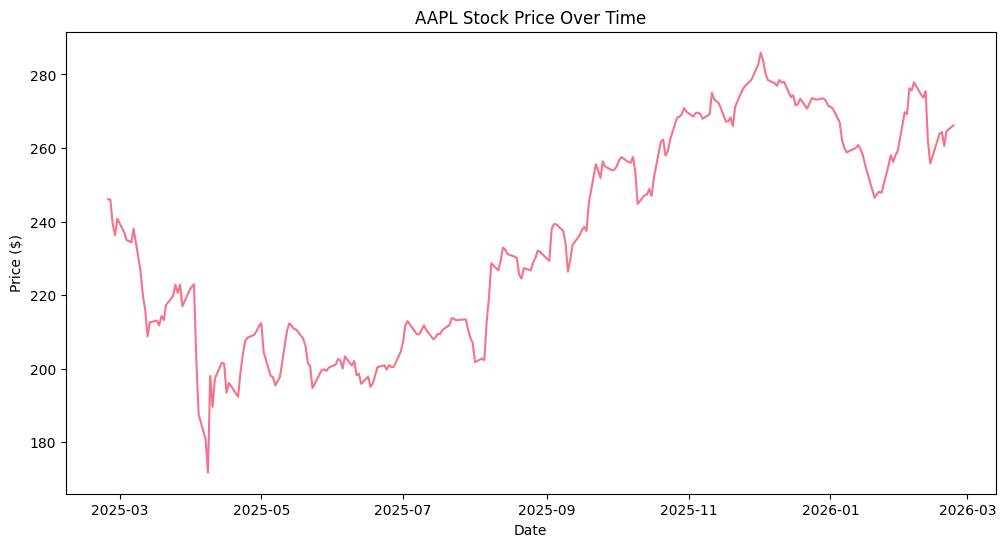

In [6]:
# Plot stock price over time
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'])
plt.title(f'{ticker} Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()


In [7]:
# Preprocess data and add technical indicators
processed_data = preprocessor.clean_stock_data(stock_data)
processed_data = preprocessor.add_technical_indicators(processed_data)

print("Technical indicators added:")
processed_data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD']].tail()


Technical indicators added:


Price,Close,SMA_20,SMA_50,RSI,MACD
Ticker,AAPL,,,,
Date,,,,,
2026-02-17,263.880005,262.520455,266.850142,54.915067,0.880633
2026-02-18,264.350006,263.414487,266.528390,57.005377,0.669985
2026-02-19,260.579987,264.072562,266.169602,52.114367,0.196570
2026-02-20,264.579987,264.895669,265.908597,54.246835,0.142509
2026-02-23,266.179993,265.814262,265.693780,46.686194,0.226166


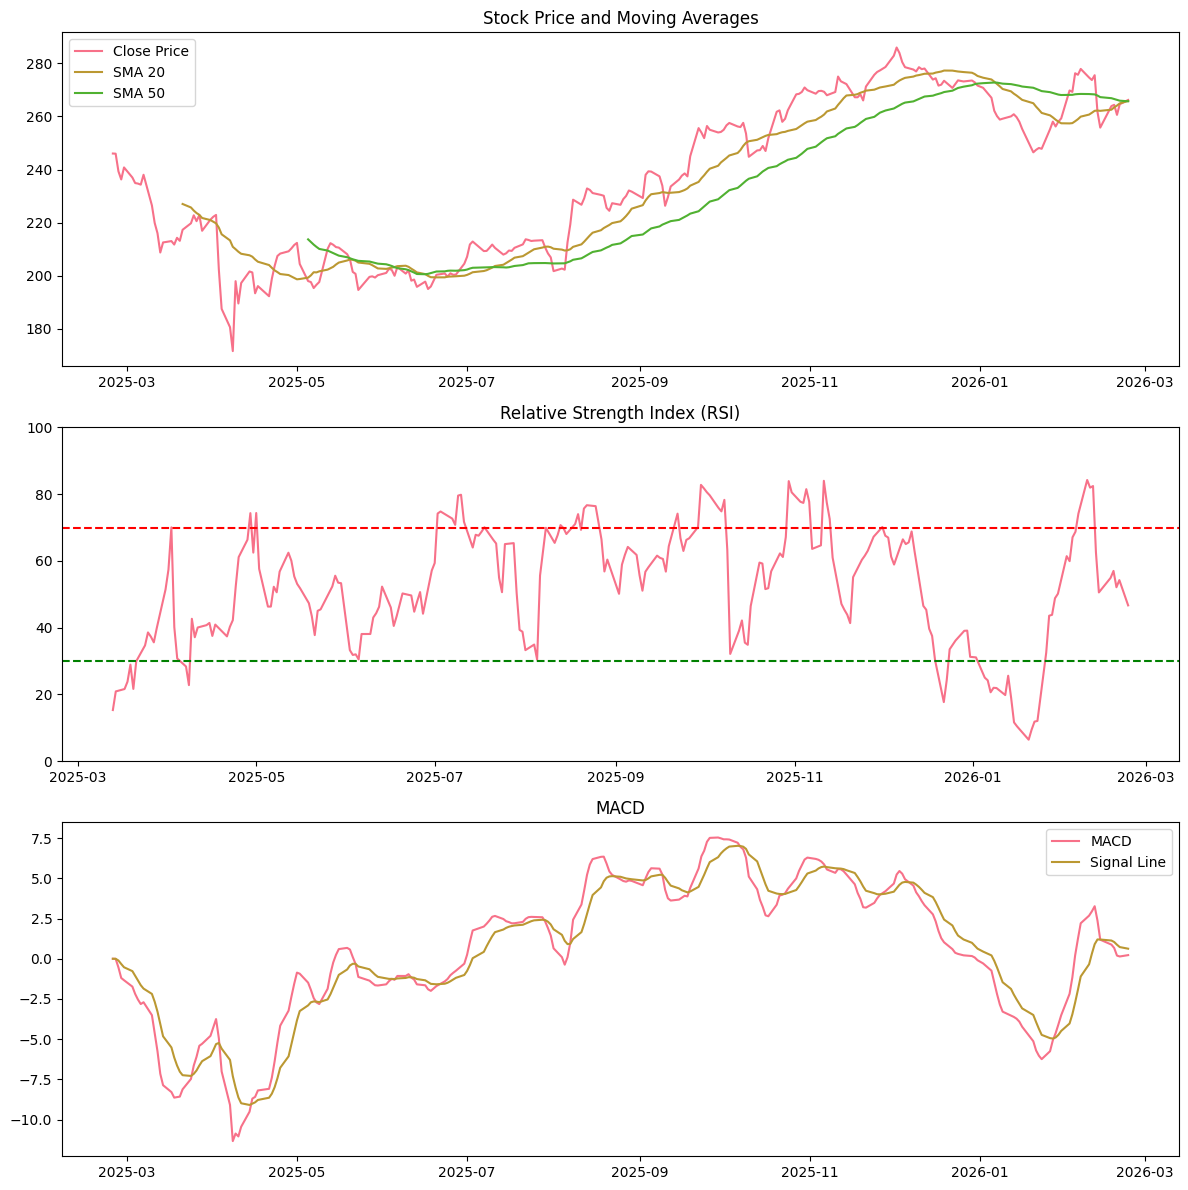

In [8]:
# Plot technical indicators
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Price and moving averages
ax1.plot(processed_data.index, processed_data['Close'], label='Close Price')
ax1.plot(processed_data.index, processed_data['SMA_20'], label='SMA 20')
ax1.plot(processed_data.index, processed_data['SMA_50'], label='SMA 50')
ax1.set_title('Stock Price and Moving Averages')
ax1.legend()

# RSI
ax2.plot(processed_data.index, processed_data['RSI'])
ax2.axhline(y=70, color='r', linestyle='--')
ax2.axhline(y=30, color='g', linestyle='--')
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylim(0, 100)

# MACD
ax3.plot(processed_data.index, processed_data['MACD'], label='MACD')
ax3.plot(processed_data.index, processed_data['Signal_Line'], label='Signal Line')
ax3.set_title('MACD')
ax3.legend()

plt.tight_layout()
plt.show()


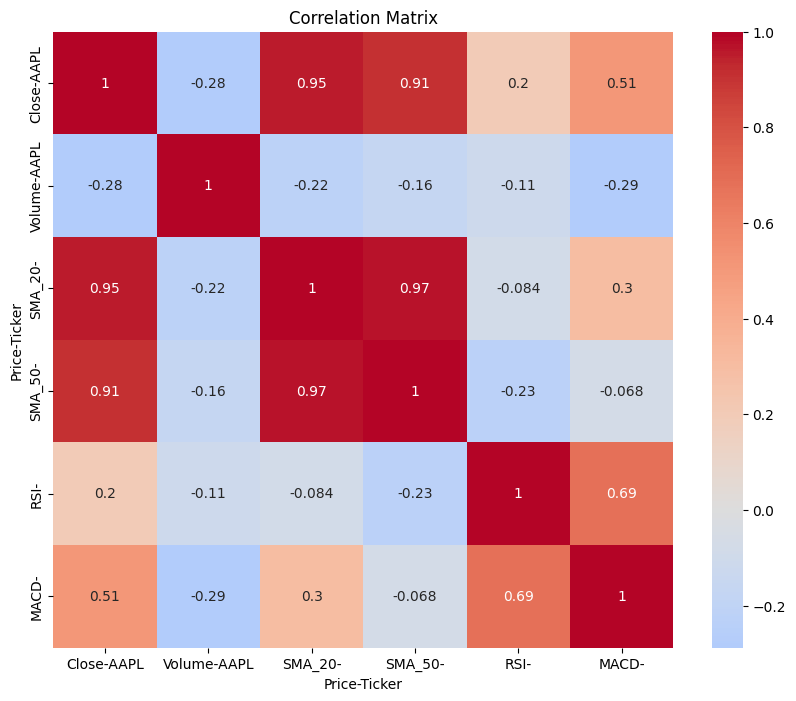

In [9]:
# Correlation analysis
correlation_matrix = processed_data[['Close', 'Volume', 'SMA_20', 'SMA_50', 'RSI', 'MACD']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


## Next Steps

1. Collect news and social media data
2. Perform sentiment analysis
3. Train baseline models
4. Implement deep learning models
5. Integrate LLM components
6. Evaluate and compare models